## Read XTCAV and STCAV from ProfMon

In [58]:
import numpy as np
import os

import h5py

from skimage.filters import sobel
from skimage.util import img_as_ubyte
from skimage.segmentation import watershed
from skimage.filters.rank import median
from skimage.morphology import disk
from pmd_beamphysics.units import mec2, c_light
import scipy.ndimage as ndimage

import matplotlib.pyplot as plt
import epics
import scipy


In [59]:
# Nicer plotting
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [81]:
def write_distgen_xy_dist(filename, image, resolution, resolution_units='um'):
    """
    Writes image data in distgen's xy_dist format
    
    Returns the absolute path to the file written
    
    """
    
    # Get width of each dimension
    widths = resolution * np.array(image.shape)
    
    center_y = 0
    center_x = 0
    
    # Form header
    header = f"""x {widths[1]} {center_x} [{resolution_units}]
y {widths[0]} {center_y}  [{resolution_units}]"""
    
    # Save with the correct orientation
    np.savetxt(filename, np.flip(image, axis=0), header=header, comments='')
    
    return os.path.abspath(filename)

## Get Initial beam from STCAV

In [82]:
data_filename = 'STCAV_data/ProfMon-OTRS_DIAG0_525-2025-10-10-223757.mat'

In [71]:
#scaling parameters
energy_res = 10090  # um / MeV   http://physics-elog.slac.stanford.edu/lcls2elog/show.jsp?dir=/2025/14/05.04&pos=2025-04-05T18:00:57
z_res  = 699#777#799 # um/degree

In [72]:
import scipy.io

In [73]:
f = h5py.File(data_filename, 'r')

In [74]:
print(f['data'].keys())

<KeysViewHDF5 ['back', 'bitdepth', 'centerX', 'centerY', 'filtOD', 'filtStat', 'img', 'imgAttn', 'isRaw', 'nCol', 'nRow', 'name', 'orientX', 'orientY', 'pulseId', 'res', 'roiX', 'roiXN', 'roiY', 'roiYN', 'ts']>


In [75]:
img = np.array(f['data']['img'])

/lscratch/jytang/tmp/ipykernel_4163199/1105185536.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  img = np.array(f['data']['img'])


In [76]:
f.close()

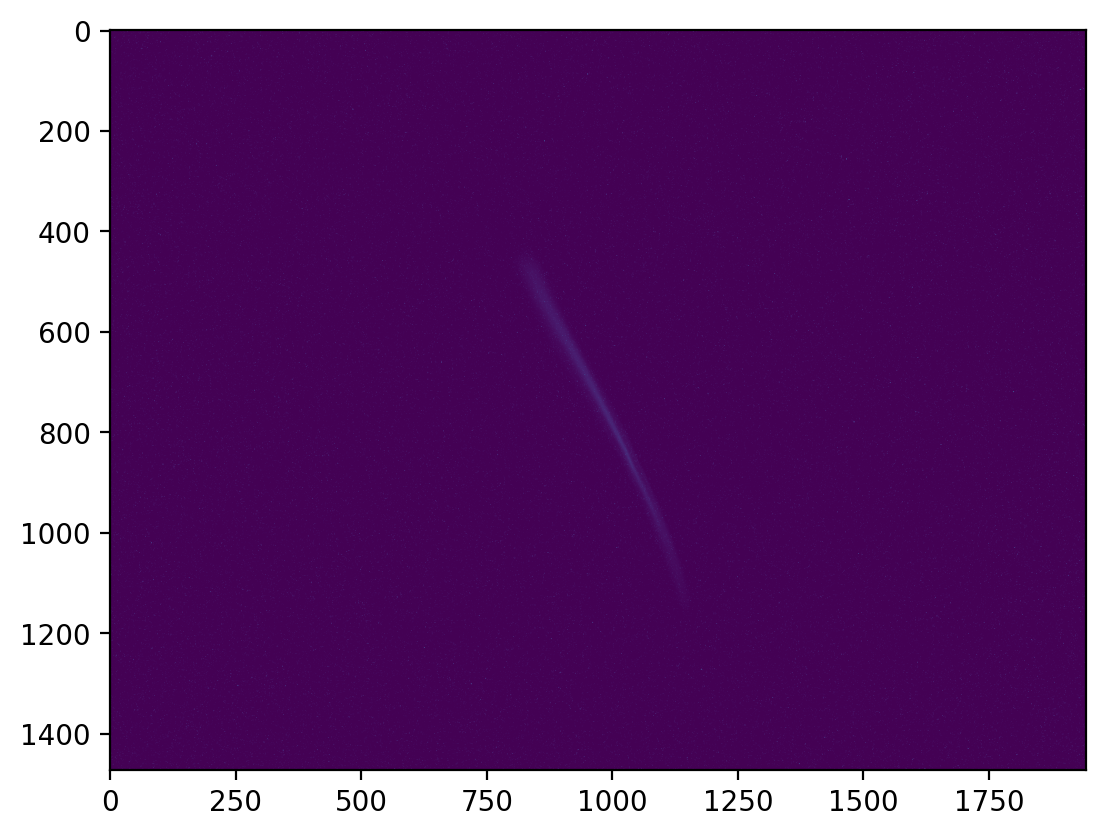

In [77]:
plt.imshow(img)

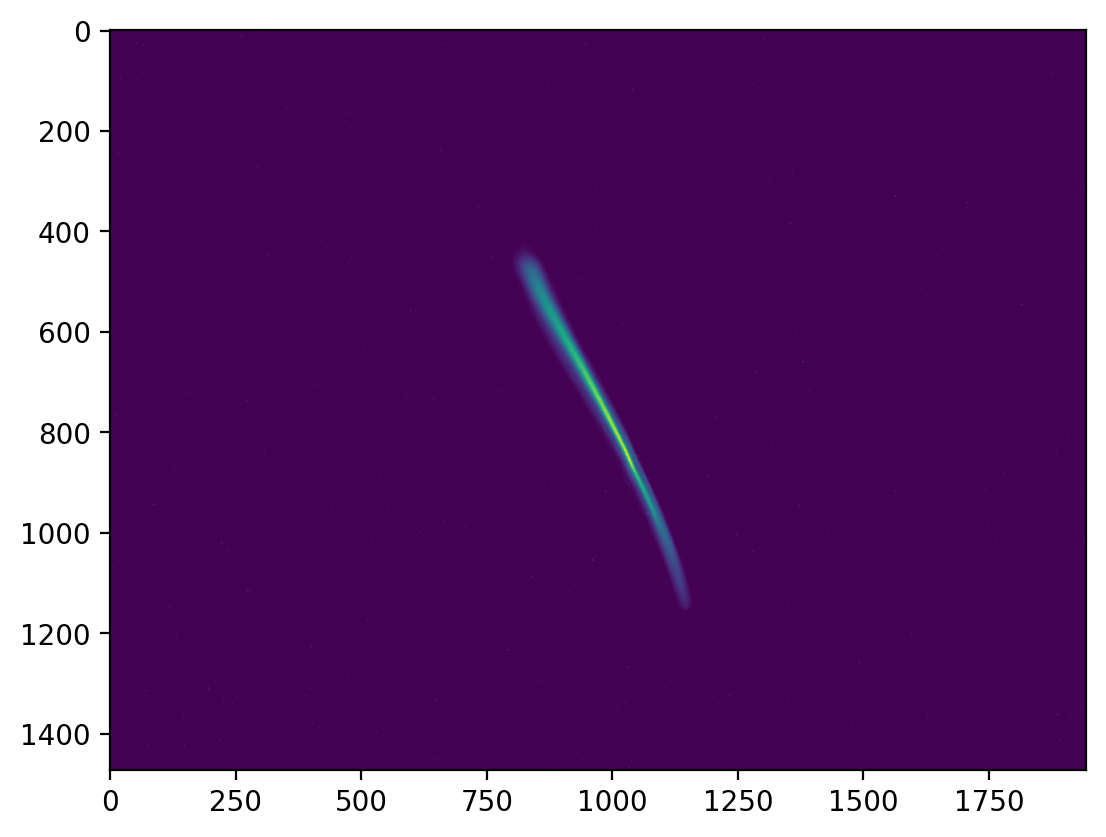

In [78]:
img3 = scipy.ndimage.median_filter(img, size = (3,3))
img3 = img3
plt.imshow(img3)

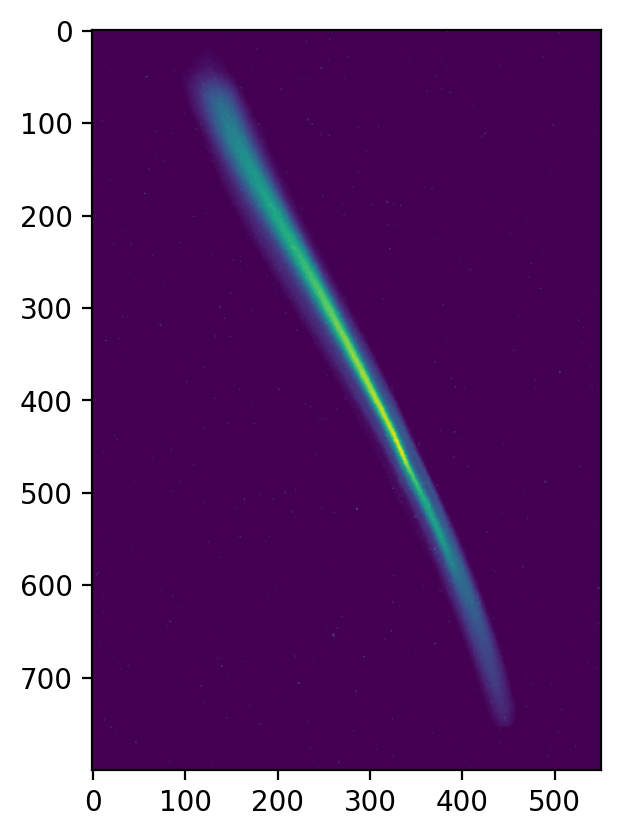

In [80]:
img_cut = img3[400:1200, 700:1250]
plt.imshow(img_cut)